In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
def sample_dataset(X, y, train_size=1000, imbalance=False, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    X, y = X[idx], y[idx]

    if imbalance:
        mask = y < 5
        X_major = X[mask][:int(0.8 * train_size)]
        y_major = y[mask][:int(0.8 * train_size)]

        X_minor = X[~mask][:int(0.2 * train_size)]
        y_minor = y[~mask][:int(0.2 * train_size)]

        X = np.concatenate([X_major, X_minor])
        y = np.concatenate([y_major, y_minor])
    else:
        X = X[:train_size]
        y = y[:train_size]

    return X, y

In [3]:
def apply_shift(X, shift_type="none"):
    if shift_type == "noise":
        return np.clip(X + 0.3 * np.random.randn(*X.shape), 0, 1)
    if shift_type == "invert":
        return 1.0 - X
    return X

In [4]:
def build_logreg():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(10, activation="softmax")
    ])
    return model
def build_mlp(hidden_units=128, l2=0.0):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(hidden_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dense(10, activation="softmax")
    ])
    return model
def build_cnn(filters=32):
    model = models.Sequential([
        layers.Conv2D(filters, 3, activation="relu", input_shape=(28,28,1)),
        layers.MaxPool2D(),
        layers.Conv2D(filters*2, 3, activation="relu"),
        layers.MaxPool2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

In [5]:
def train_and_evaluate(model, X_tr, y_tr, X_val, y_val, X_te, y_te, epochs=20):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        verbose=0
    )

    tr_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    te_loss, te_acc = model.evaluate(X_te, y_te, verbose=0)

    gap = tr_acc - val_acc

    return {
        "train_acc": tr_acc,
        "val_acc": val_acc,
        "test_acc": te_acc,
        "gap": gap,
        "epochs": epochs,
        "val_curve": history.history["val_accuracy"]
    }

In [35]:
def diagnose(metrics,
             acc_thresh=0.7,
             train_ready=0.6,
             gap_thresh=0.15,
             patience=3):

    train_acc = metrics["train_acc"]
    val_acc = metrics["val_acc"]

    epoch = len(train_acc)

    gap_series = [train_acc[i] - val_acc[i] for i in range(epoch)]
    gap = gap_series[-1]

    # -------- UNDERFITTING --------

    underfitting = int(train_acc[-1] < acc_thresh)

    # -------- OVERFITTING --------

    overfitting = 0

    if train_acc[-1] > train_ready and epoch > patience:

        # 1) validation хуже своего лучшего значения
        best_val = max(val_acc[:-1])
        val_drop = val_acc[-1] < best_val - 0.01

        # 2) gap стабильно большой
        gap_large = gap > gap_thresh

        if val_drop or gap_large:
            overfitting = 1

    return {
        "underfitting": underfitting,
        "overfitting": overfitting,
        "dataset_shift": int(metrics["val_acc"][-1] - metrics["test_acc"][-1] > 0.15),
        }



In [22]:
def train_with_history(model, X_tr, y_tr, X_val, y_val, X_te, y_te, max_epochs=30):
    history = []

    train_acc_curve = []
    val_acc_curve = []
    test_acc_curve = []
    train_loss_curve = []
    val_loss_curve = []

    for epoch in range(1, max_epochs + 1):
        # тренируем модель 1 эпоху
        his = model.fit(
            X_tr, y_tr,
            epochs=1,
            verbose=0,
            validation_data=(X_val, y_val)
        )

        # метрики текущей эпохи
        tr_acc = his.history["accuracy"][0]
        val_acc = his.history["val_accuracy"][0]
        tr_loss = his.history["loss"][0]
        val_loss = his.history["val_loss"][0]

        # оценка на тесте
        _, te_acc = model.evaluate(X_te, y_te, verbose=0)

        # обновляем кривые
        train_acc_curve.append(tr_acc)
        val_acc_curve.append(val_acc)
        test_acc_curve.append(te_acc)
        train_loss_curve.append(tr_loss)
        val_loss_curve.append(val_loss)

        # создаем запись с массивами до текущей эпохи
        history.append({
            "epoch": epoch,
            "train_acc": train_acc_curve.copy(),
            "val_acc": val_acc_curve.copy(),
            "test_acc": test_acc_curve.copy(),
            "train_loss": train_loss_curve.copy(),
            "val_loss": val_loss_curve.copy(),
            "gap": tr_acc - val_acc
        })

    return history

In [40]:
import itertools

rows = []

model_builders = [
    ("logreg", build_logreg),
    ("mlp_small", lambda: build_mlp(64, l2=0.001)),
    ("mlp_large", lambda: build_mlp(256, l2=0.0)),
    ("cnn_small", lambda: build_cnn(16)),
    ("cnn_large", lambda: build_cnn(32))
]

train_sizes = [50, 100, 200, 500, 1000, 2000]
seeds = list(range(1))  # 10 random seeds
imbalance_flags = [False, True]
shift_types = ["none", "noise", "invert"]

for model_name, builder in model_builders:
    for train_size, seed, imbalance, shift in itertools.product(
        train_sizes, seeds, imbalance_flags, shift_types
    ):

        X_tr, y_tr = sample_dataset(X_train, y_train, train_size=train_size,
                                    imbalance=imbalance, seed=seed)
        X_val, y_val = X_test[:1000], y_test[:1000]
        X_te = apply_shift(X_test, shift_type=shift)
        model = builder()
        model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        history = train_with_history(
            model, X_tr, y_tr, X_val, y_val, X_te, y_test, max_epochs=30
        )

        for metrics in history:
            labels = diagnose(metrics)  # если нужны метки

            rows.append({
                "model": model_name,
                "train_size": train_size,
                "seed": seed,
                "imbalance": imbalance,
                "shift_type": shift,
                **metrics,  # train_acc, val_acc, test_acc, train_loss, val_loss
                **labels
            })

        print(model_name, train_size, seed, imbalance, shift)
df = pd.DataFrame(rows)
print(f"Размер датасета: {len(df)} экспериментов")
print(df.head(10))  # вывод первых 10 строк

logreg 50 0 False none
logreg 50 0 False noise
logreg 50 0 False invert
logreg 50 0 True none
logreg 50 0 True noise
logreg 50 0 True invert
logreg 100 0 False none
logreg 100 0 False noise
logreg 100 0 False invert
logreg 100 0 True none
logreg 100 0 True noise
logreg 100 0 True invert
logreg 200 0 False none
logreg 200 0 False noise
logreg 200 0 False invert
logreg 200 0 True none
logreg 200 0 True noise
logreg 200 0 True invert
logreg 500 0 False none
logreg 500 0 False noise
logreg 500 0 False invert
logreg 500 0 True none
logreg 500 0 True noise
logreg 500 0 True invert
logreg 1000 0 False none
logreg 1000 0 False noise
logreg 1000 0 False invert
logreg 1000 0 True none
logreg 1000 0 True noise
logreg 1000 0 True invert
logreg 2000 0 False none
logreg 2000 0 False noise
logreg 2000 0 False invert
logreg 2000 0 True none
logreg 2000 0 True noise
logreg 2000 0 True invert
mlp_small 50 0 False none
mlp_small 50 0 False noise
mlp_small 50 0 False invert
mlp_small 50 0 True none
mlp_sm

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


cnn_small 50 0 False none
cnn_small 50 0 False noise
cnn_small 50 0 False invert
cnn_small 50 0 True none
cnn_small 50 0 True noise
cnn_small 50 0 True invert
cnn_small 100 0 False none
cnn_small 100 0 False noise
cnn_small 100 0 False invert
cnn_small 100 0 True none
cnn_small 100 0 True noise
cnn_small 100 0 True invert
cnn_small 200 0 False none
cnn_small 200 0 False noise
cnn_small 200 0 False invert
cnn_small 200 0 True none
cnn_small 200 0 True noise
cnn_small 200 0 True invert
cnn_small 500 0 False none
cnn_small 500 0 False noise
cnn_small 500 0 False invert
cnn_small 500 0 True none
cnn_small 500 0 True noise
cnn_small 500 0 True invert
cnn_small 1000 0 False none
cnn_small 1000 0 False noise
cnn_small 1000 0 False invert
cnn_small 1000 0 True none
cnn_small 1000 0 True noise
cnn_small 1000 0 True invert
cnn_small 2000 0 False none
cnn_small 2000 0 False noise
cnn_small 2000 0 False invert
cnn_small 2000 0 True none
cnn_small 2000 0 True noise
cnn_small 2000 0 True invert
cnn_

In [41]:
df.to_csv('dhhdfh.csv', sep=';')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

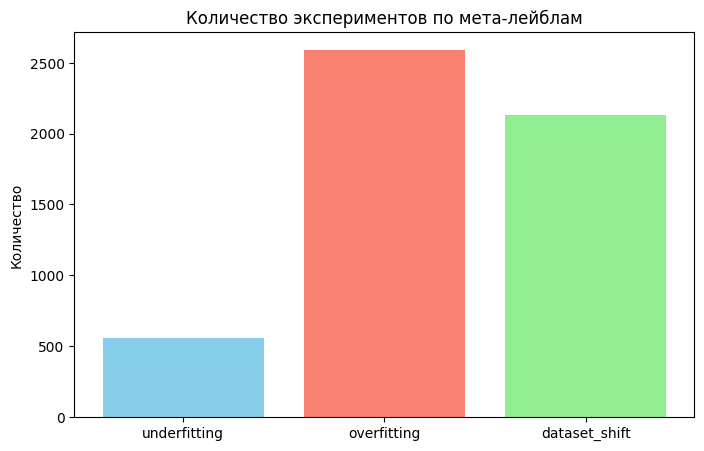

In [42]:
import matplotlib.pyplot as plt

# Считаем количество экспериментов с каждым мета-лейблом
meta_labels = ["underfitting", "overfitting", "dataset_shift"]

counts = {label: df[label].sum() for label in meta_labels}

plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values(), color=["skyblue","salmon","lightgreen"])
plt.title("Количество экспериментов по мета-лейблам")
plt.ylabel("Количество")
plt.show()

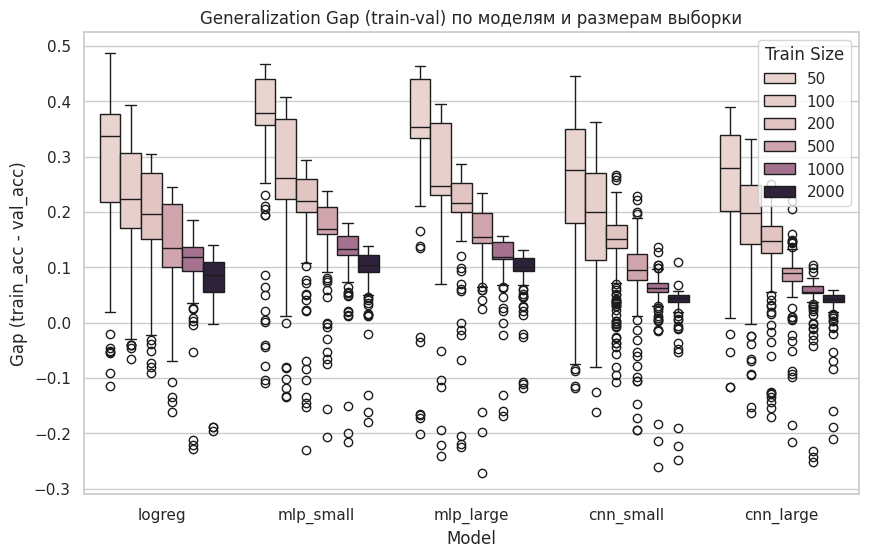

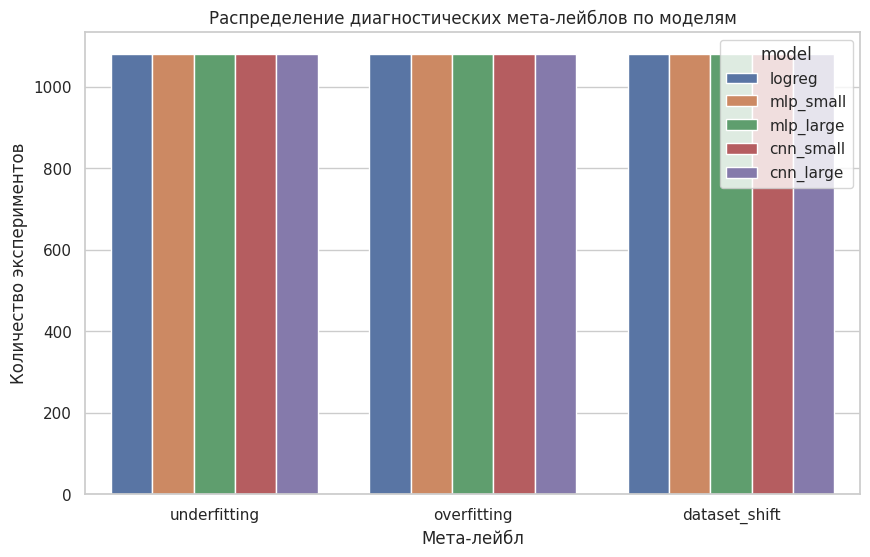

TypeError: unhashable type: 'list'

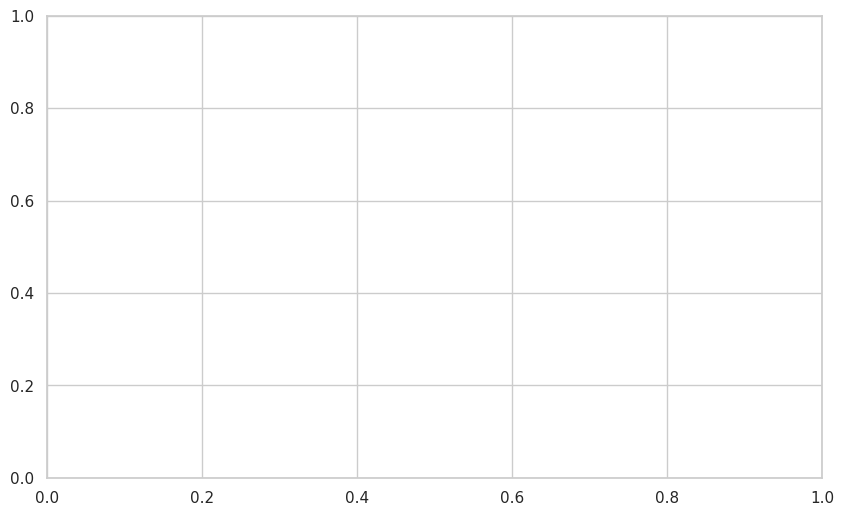

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# # 1️⃣ Распределение accuracy по моделям
# plt.figure(figsize=(10,6))
# sns.boxplot(x="model", y="test_acc", data=df)
# plt.title("Test Accuracy распределение по моделям")
# plt.ylabel("Test Accuracy")
# plt.xlabel("Model")
# plt.show()

# 2️⃣ Gap train-val по моделям (визуально overfitting)
plt.figure(figsize=(10,6))
sns.boxplot(x="model", y="gap", hue="train_size", data=df)
plt.title("Generalization Gap (train-val) по моделям и размерам выборки")
plt.ylabel("Gap (train_acc - val_acc)")
plt.xlabel("Model")
plt.legend(title="Train Size")
plt.show()

# 3️⃣ Распределение мета-лейблов (заблуждений)
plt.figure(figsize=(10,6))
meta_labels = ["underfitting", "overfitting", "dataset_shift"]
df_melted = df.melt(id_vars=["model"], value_vars=meta_labels, var_name="label", value_name="presence")
sns.countplot(x="label", hue="model", data=df_melted)
plt.title("Распределение диагностических мета-лейблов по моделям")
plt.ylabel("Количество экспериментов")
plt.xlabel("Мета-лейбл")
plt.show()
